<div style="background-color:#e6f2ff; padding:20px; border-radius:10px;">
<img style="float:left; margin-right:20px;" src='Figures/alinco.png' width="120"/>
<h1 style="color:#000047;">Actividad 3: Similitud Semantica con Word2Vec</h1>
<br style="clear:both"/>
</div>

<div style="border-left:4px solid #000047; padding:10px; margin-top:10px; background:#f5f5f5;">
<b>Objetivo:</b> Aplicar Word2Vec para calcular similitud semantica y encontrar palabras analogas.
</div>

<div style="margin-top:10px;">
<b>Instrucciones generales:</b>
<ul>
<li>Entrena un modelo Word2Vec con el corpus provisto</li>
<li>Encuentra las 5 palabras mas similares a palabras clave</li>
<li>Calcula similitudes entre grupos de palabras</li>
<li>Visualiza los embeddings con PCA</li>
<li>Construye un sistema de busqueda semantica simple</li>

</ul>
</div>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
import warnings
from gensim.models import Word2Vec
import re
from gensim.models import FastText
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
# Calcular similitud coseno entre pares
from sklearn.metrics.pairwise import cosine_similarity
# Reduccion de dimensionalidad para visualizar los embeddings
from sklearn.decomposition import PCA

In [11]:
# -----------------------------------------
# 0. Cargando los datos del archivo de texto
# -----------------------------------------

with open('Data/shakespeare.txt', encoding='utf-8') as f:
    data = f.read()

print(f'Caracteres: {len(data)}')

Caracteres: 306996


In [12]:
# Tokenizar: cada linea -> lista de palabras en minusculas (solo letras y apostrofes)
lineas = [l for l in data.split('\n') if l.strip()]
sentences = [re.findall(r"[a-z']+", linea.lower()) for linea in lineas]

# Conservar solo oraciones con al menos 2 tokens (necesario para tener contexto)
sentences = [s for s in sentences if len(s) >= 2]

print(f'Oraciones (lineas): {len(sentences)}')
print(f'Tokens totales:     {sum(len(s) for s in sentences)}')

Oraciones (lineas): 6434
Tokens totales:     52159


In [14]:
# -----------------------------------------
# 1. Enrenamiento del modelo Word2Vec
# -----------------------------------------

model = Word2Vec(
    sentences=sentences,
    vector_size=100,   # dimension del embedding
    window=5,          
    min_count=1,       # incluimos todas las palabras 
    sg=1,              
    epochs=50,
    seed=42,
    workers=1
)

print(f'Vocabulario: {len(model.wv)} palabras')
print(f'Dimension del embedding: {model.vector_size}')

print('\nVector de "king" (primeras 5 dimensiones):')
print(model.wv['king'][:5])

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Vocabulario: 6354 palabras
Dimension del embedding: 100

Vector de "king" (primeras 5 dimensiones):
[ 0.90354973 -0.18134233  0.42544162  0.7466935   0.12503025]


In [15]:
# -----------------------------------------
# 2. Palabras mas similares (top 5) para cada palabra clave
# -----------------------------------------

palabras_clave = ['crooked', 'king', 'love', 'death', 'heart']

print('Palabras más similares (top 5):')
for palabra in palabras_clave:
    if palabra in model.wv:
        similares = model.wv.most_similar(palabra, topn=5)
        print(f'\n{palabra} ----->')
        for w, s in similares:
            print(f'   {w:<15} {s:.3f}')
    else:
        print(f'\n{palabra}: no esta en el vocabulario')

Palabras más similares (top 5):

crooked ----->
   eclipses        0.800
   imbar           0.770
   figure          0.751
   prevent'st      0.750
   divisions       0.747

king ----->
   pepin           0.524
   henry           0.508
   childeric       0.498
   deposed         0.495
   v               0.491

love ----->
   jade            0.511
   dearly          0.501
   t'              0.501
   rise            0.495
   waters          0.494

death ----->
   churl           0.615
   subscribes      0.594
   lady's          0.570
   immortal        0.569
   dust            0.565

heart ----->
   raiment         0.567
   glance          0.553
   seemly          0.550
   committed       0.535
   league          0.533


In [16]:
# -----------------------------------------
# 3. Similitud entre grupos de palabras
# -----------------------------------------

def matriz_similitud(grupo, modelo):
    grupo = [w for w in grupo if w in modelo.wv]   # filtrar palabras fuera de vocabulario
    n = len(grupo)
    M = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            M[i, j] = modelo.wv.similarity(grupo[i], grupo[j])
    return grupo, M


def mostrar_matriz(grupo, M):
    ancho = max(len(w) for w in grupo) + 2
    print(' ' * ancho + ''.join(f'{w[:7]:>9}' for w in grupo))
    for i, w in enumerate(grupo):
        fila = ''.join(f'{M[i, j]:>9.3f}' for j in range(len(grupo)))
        print(f'{w:<{ancho}}{fila}')


grupo = ['imperfections', 'devout', 'ascend', 'king', 'love']
grupo_ok, M = matriz_similitud(grupo, model)

print('Similitud entre grupos de palabras:\n')
mostrar_matriz(grupo_ok, M)

Similitud entre grupos de palabras:

                 imperfe   devout   ascend     king     love
imperfections      1.000    0.687    0.574    0.249    0.226
devout             0.687    1.000    0.722    0.292    0.292
ascend             0.574    0.722    1.000    0.247    0.355
king               0.249    0.292    0.247    1.000    0.101
love               0.226    0.292    0.355    0.101    1.000


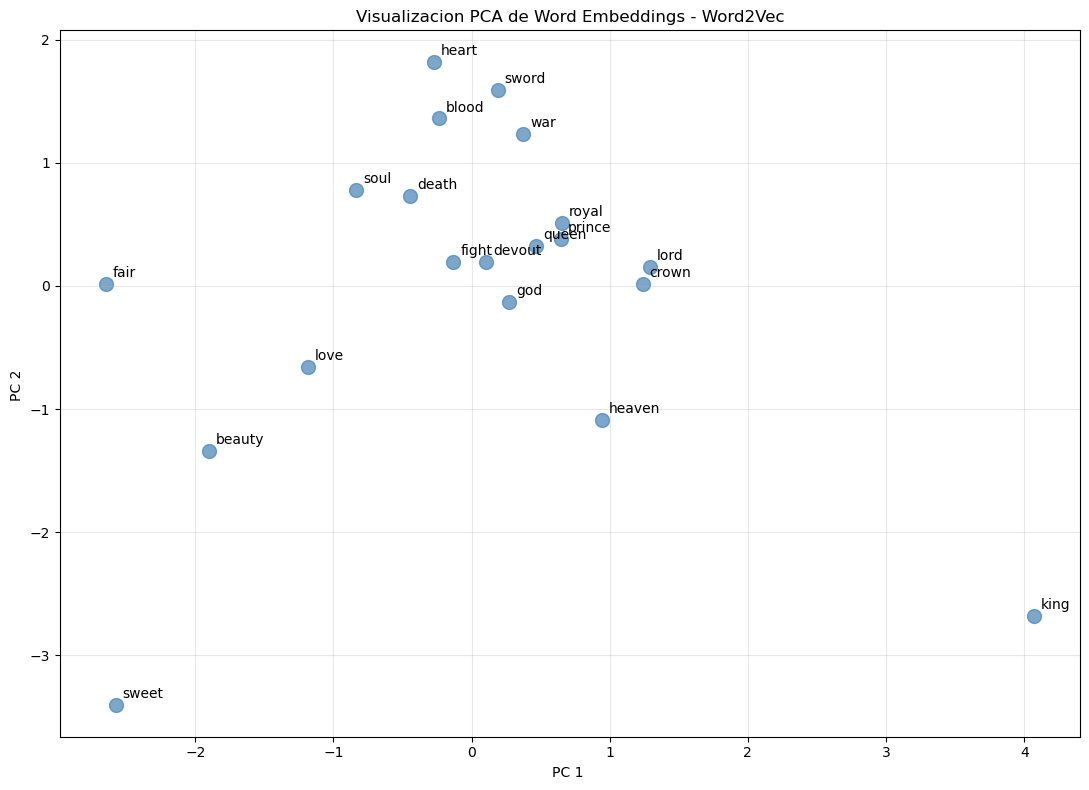

In [ ]:
# -----------------------------------------
# 4. Visualizacion de Embeddings con PCA
# -----------------------------------------

words_to_plot = [
    # realeza
    'king', 'queen', 'crown', 'prince', 'lord', 'royal',
    # emociones / amor
    'love', 'heart', 'sweet', 'fair', 'beauty',
    # guerra / muerte
    'war', 'death', 'blood', 'sword', 'fight',
    # religion
    'god', 'heaven', 'soul', 'devout',
]
words_to_plot = [w for w in words_to_plot if w in model.wv]
X = np.array([model.wv[w] for w in words_to_plot])

# PCA a 2 dimensiones
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X)

plt.figure(figsize=(11, 8))
plt.scatter(coords[:, 0], coords[:, 1], c='steelblue', s=100, alpha=0.7)
for i, word in enumerate(words_to_plot):
    plt.annotate(word, coords[i], textcoords='offset points', xytext=(5, 5), fontsize=10)

plt.title('Visualizacion PCA de Word Embeddings - Word2Vec', fontsize=12)
plt.xlabel(f'PC 1 ')
plt.ylabel(f'PC 2 ')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# -----------------------------------------
# 5. Sistema de busqueda semantica simple
# -----------------------------------------

def sentence_embedding_avg(oracion, modelo):
    tokens = re.findall(r"[a-z']+", oracion.lower())
    vecs = [modelo.wv[t] for t in tokens if t in modelo.wv]
    if not vecs:
        return np.zeros(modelo.vector_size)
    return np.mean(vecs, axis=0)


class BuscadorSemantico:

    def __init__(self, corpus, modelo):
        self.corpus = corpus
        self.modelo = modelo
        self.embeddings = np.array([sentence_embedding_avg(doc, modelo) for doc in corpus])

    def buscar(self, query, top_n=3):
        q_emb = sentence_embedding_avg(query, self.modelo)
        if np.linalg.norm(q_emb) == 0:
            return []
        q_emb = q_emb / np.linalg.norm(q_emb)
        norms = self.embeddings / (np.linalg.norm(self.embeddings, axis=1, keepdims=True) + 1e-8)
        sims = norms @ q_emb
        indices = sims.argsort()[::-1][:top_n]
        return [(i, sims[i], self.corpus[i]) for i in indices]

In [20]:
# Corpus de busqueda (frases en ingles, tematicas presentes en el corpus de Shakespeare)
corpus_busqueda = [
    'the king rules over his kingdom and wears the crown',
    'love is a sweet and tender passion of the heart',
    'war brings death blood and sorrow to the land',
    'the queen and the prince walk in the royal court',
    'the soldier draws his sword for the battle',
    'heaven and god watch over the soul of man',
    'the fool speaks wisdom with a merry jest',
    'a fair lady with a beautiful and gentle face',
]

buscador = BuscadorSemantico(corpus_busqueda, model)

queries = [
    'a royal monarch and his throne',
    'feelings of romance and affection',
    'a fight with weapons and bloodshed',
]

for q in queries:
    resultados = buscador.buscar(q, top_n=3)
    print(f'\nConsulta: {q}')
    for rank, (idx, score, doc) in enumerate(resultados, 1):
        print(f'  [{rank}] sim={score:.3f} | {doc}')


Consulta: a royal monarch and his throne
  [1] sim=0.719 | the soldier draws his sword for the battle
  [2] sim=0.692 | a fair lady with a beautiful and gentle face
  [3] sim=0.691 | the king rules over his kingdom and wears the crown

Consulta: feelings of romance and affection
  [1] sim=0.757 | heaven and god watch over the soul of man
  [2] sim=0.718 | love is a sweet and tender passion of the heart
  [3] sim=0.714 | the queen and the prince walk in the royal court

Consulta: a fight with weapons and bloodshed
  [1] sim=0.816 | the fool speaks wisdom with a merry jest
  [2] sim=0.810 | a fair lady with a beautiful and gentle face
  [3] sim=0.575 | love is a sweet and tender passion of the heart
